In [1]:
import sys
sys.path.append('../scripts')

from analysis import load_runmap, load_baselines, load_metadata, group_grid
from plotting import plot_group_all_methods, plot_interpolated_grid, plot_groups_side_by_side

runmap_df = load_runmap()
baselines_df = load_baselines()
metadata_df = load_metadata()

SESSION = 1  # every subject has a session-1 row, so this covers everyone once

# HC = the data's CTR (control) group label
categories = [
    {'label': 'PD', 'group': 'PD'},
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'CVD', 'group': 'CVD'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]

## Each group, all normalization methods
Raw + percent/dB/z-score (baseline: `scope='run', trials='all'`), one row per group. Each panel is scaled independently -- raw and normalized values aren't on the same numeric scale.

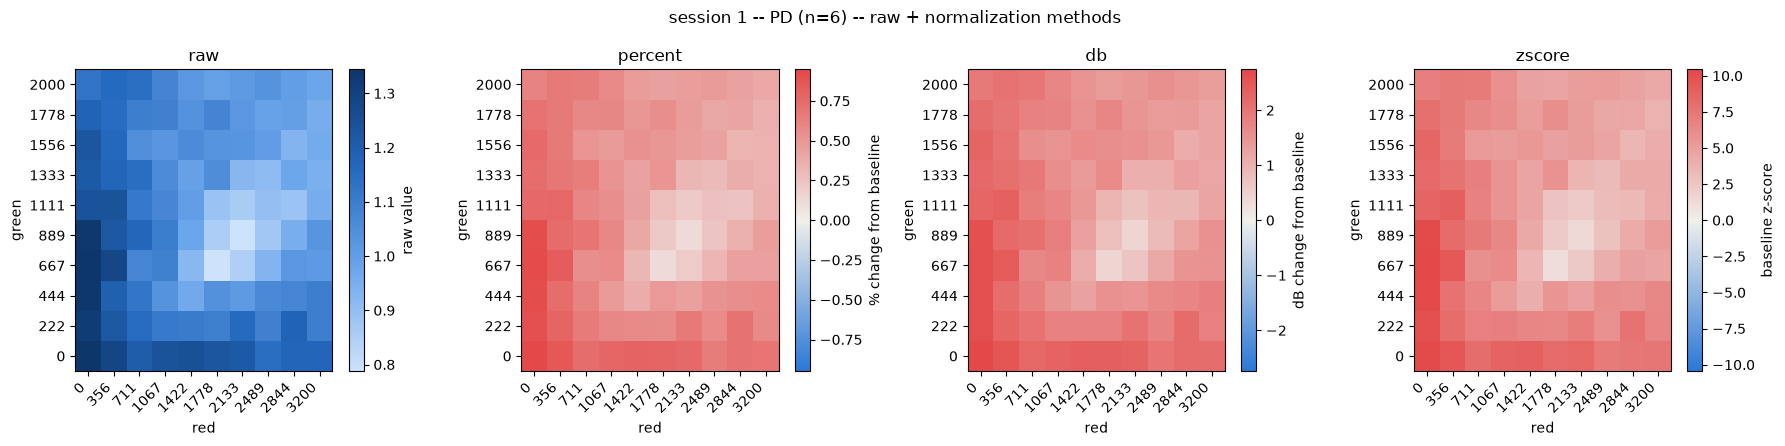

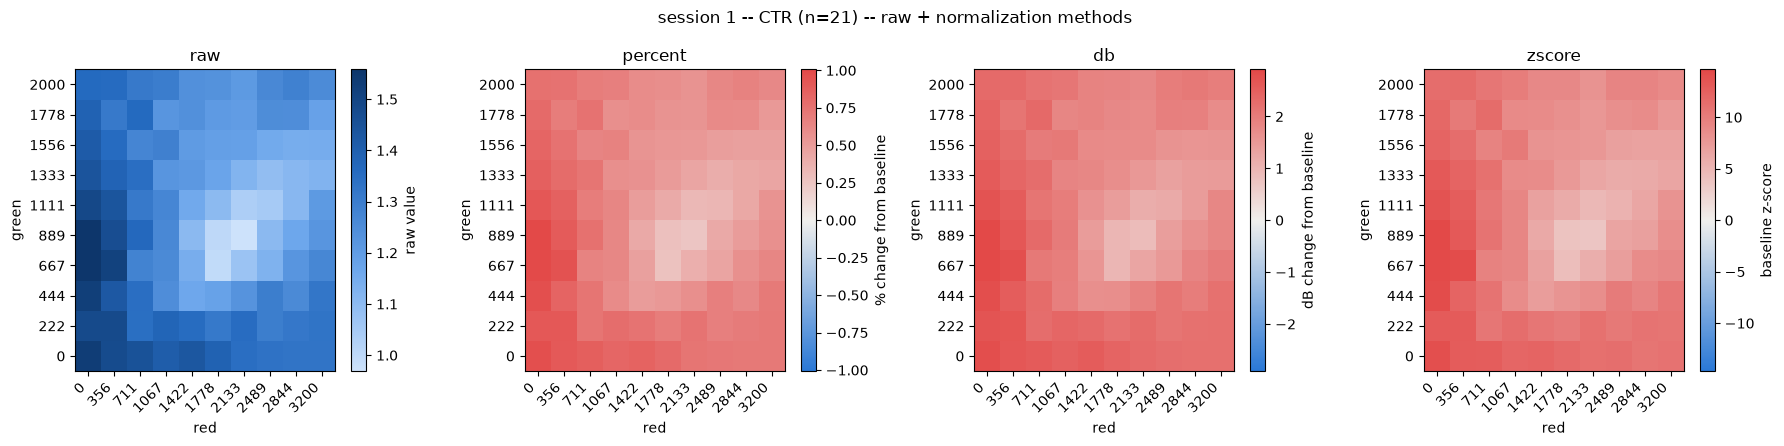

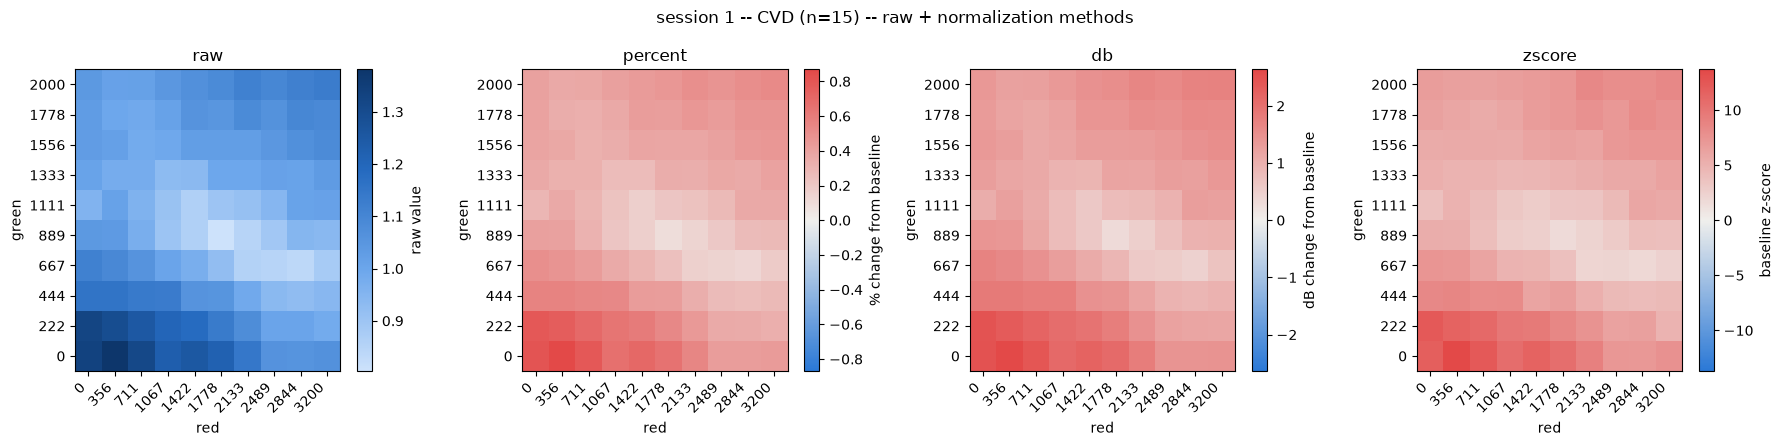

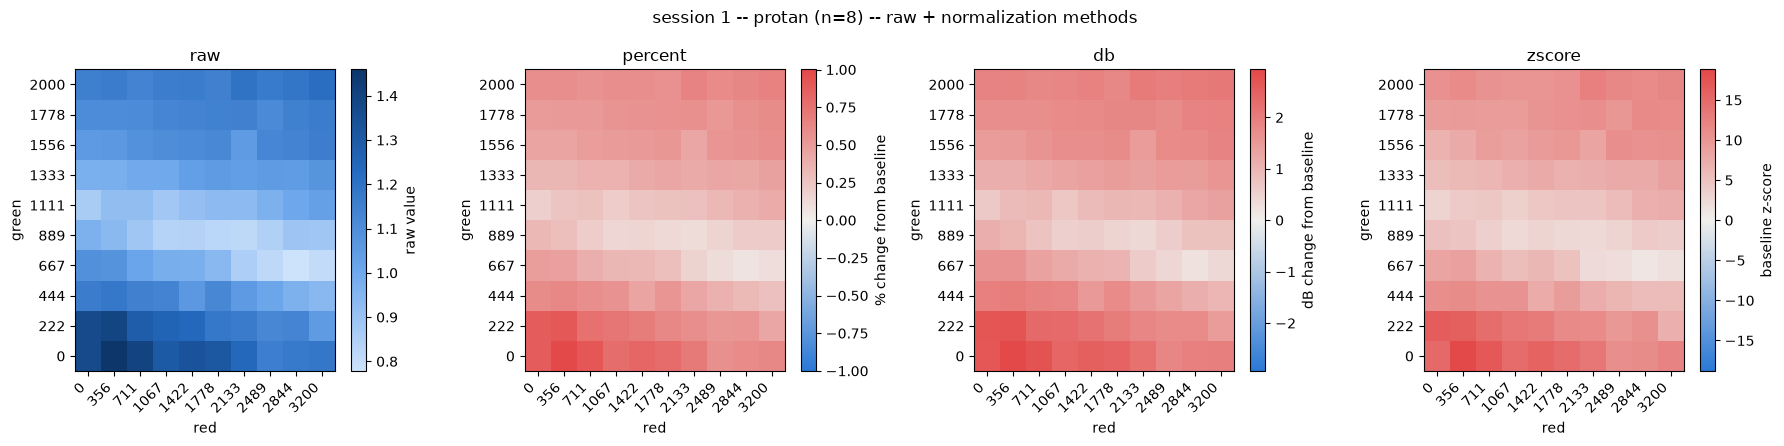

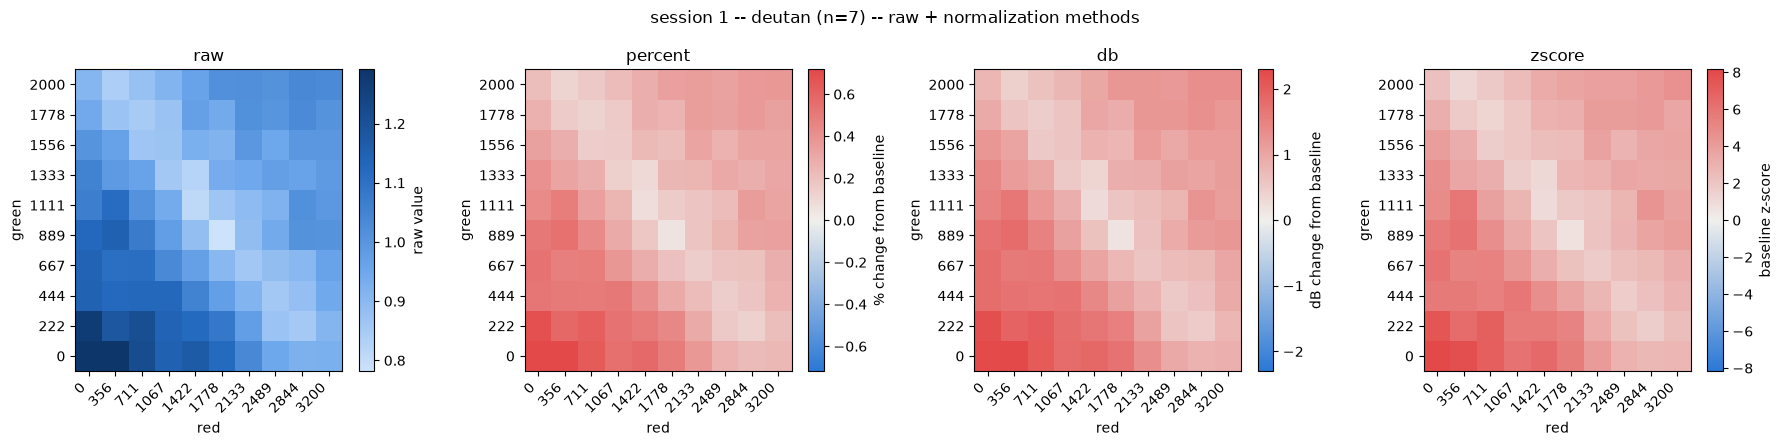

In [2]:
for cat in categories:
    plot_group_all_methods(
        runmap_df, baselines_df, metadata_df, SESSION,
        group=cat.get('group'), subgroup=cat.get('subgroup'),
    )

## Each group, interpolated to 100x100
Raw group mean map, upsampled from the native 10x10 grid via linear interpolation for a smoother view. All 5 panels share one auto-computed color scale (`clim`), so they're comparable to each other.

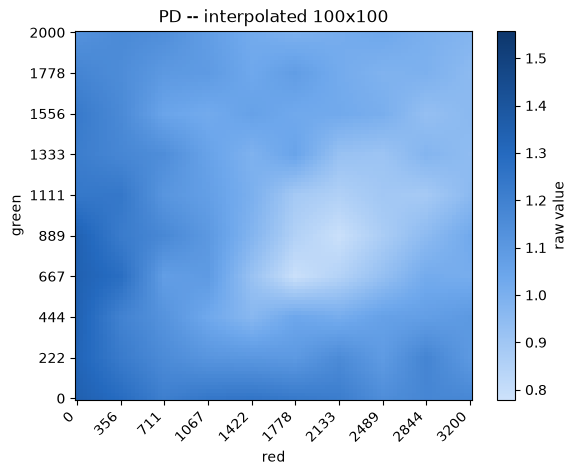

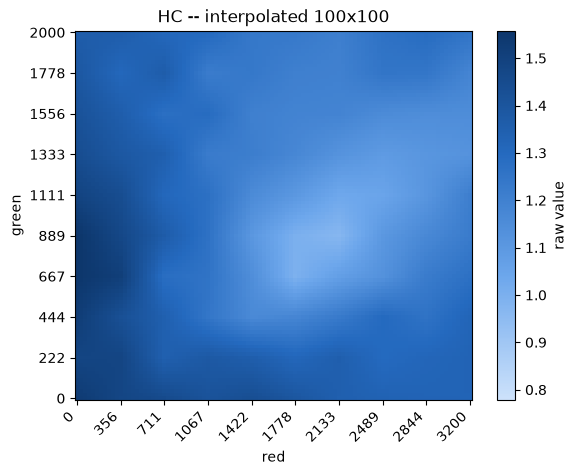

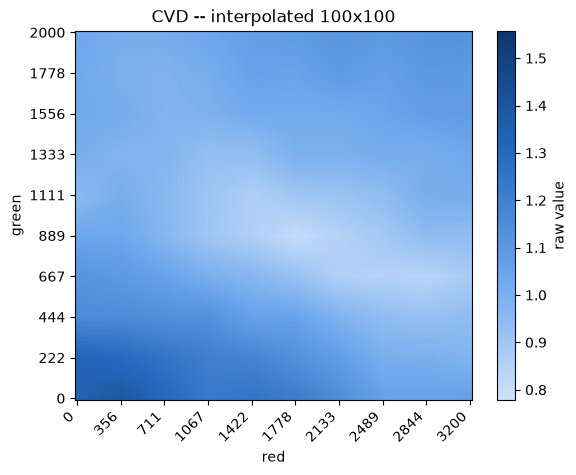

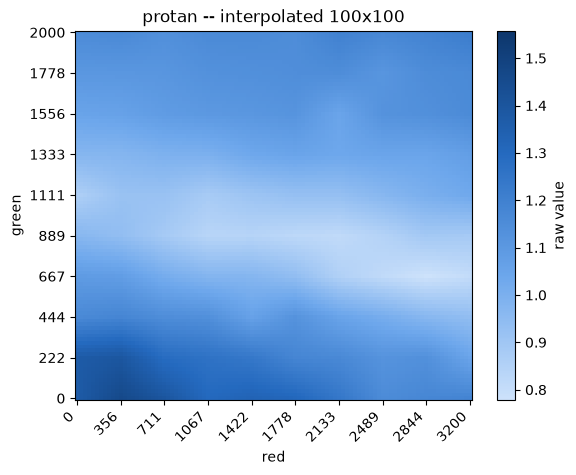

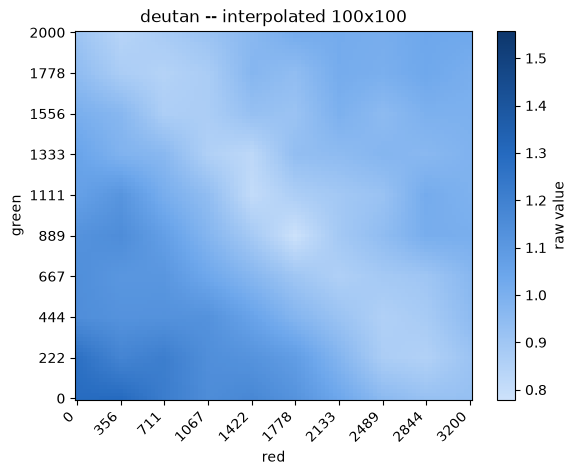

In [3]:
group_grids = {
    cat['label']: group_grid(runmap_df, baselines_df, metadata_df, SESSION, group=cat.get('group'), subgroup=cat.get('subgroup'))
    for cat in categories
}
shared_clim = (min(g.min() for g in group_grids.values()), max(g.max() for g in group_grids.values()))

for cat in categories:
    plot_interpolated_grid(
        group_grids[cat['label']], (100, 100), label='raw value', clim=shared_clim,
        title=f"{cat['label']} -- interpolated 100x100",
    )

## PD, HC, protan, deutan side by side
Raw group means, one panel per group, panel titles show sample size (n).

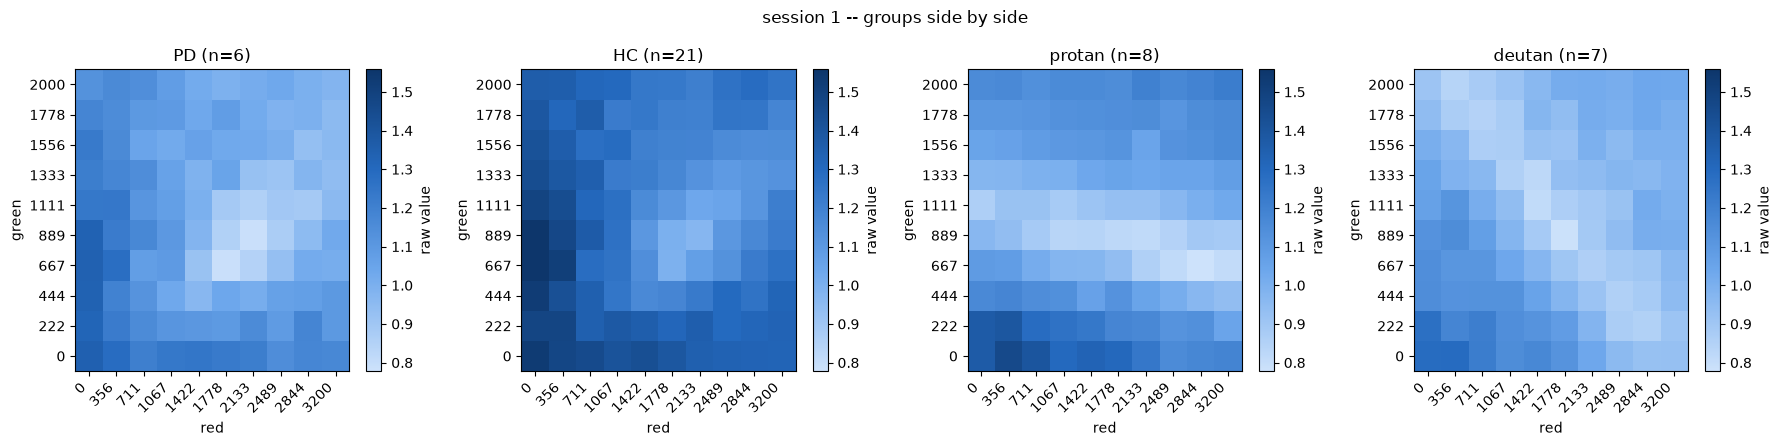

In [4]:
side_by_side_categories = [c for c in categories if c['label'] != 'CVD']
plot_groups_side_by_side(runmap_df, baselines_df, metadata_df, SESSION, side_by_side_categories);